In [1]:
from matplotlib import pyplot as plt
import json

from pathlib import Path

import pandas as pd

from scipy.stats import sem

In [2]:
DIR = Path("../../artifacts/2024-02-s20/experiments/2-accuracy-basis")

In [3]:
def load(dataset, logit_mod, arch, layer, basis_name, basis_mode, seeds=list(range(1, 5+1))):
    
    arr_dfs = []
    for seed in seeds:
        with open(DIR  / f"{dataset}-seed{seed}" / f"logit-mod-{logit_mod}" / arch / layer / f"{basis_name}--{basis_mode}" / "stats.json", "r") as fh:
            data = json.load(fh)
            
        
        df = pd.DataFrame(
            {
                "acc": data["arr_acc"],
                "k": data["arr_ks"]
            }
        )
        df["dims"] = data["dims"]

        # remark: the attribute name here is misnormzer. 
        # perhaps, we refactor it.
        df["original_acc"] = data["original_acc"]
        df["seed"] = seed
        df["num_classes"] = data["num_classes"]
            
        arr_dfs.append(df)
    
    df = pd.concat(arr_dfs).groupby(by="k").agg({
        "acc": ["mean", "std"],
        "seed": ["count"],
        "original_acc": ["first"],
        "dims": ["first"],
        "num_classes": ["first"]
    })
    
    
    assert (df["seed"]["count"] == df["seed"]["count"].values[0]).all()

    for col in ["original_acc", "dims"]:

        assert (df[col]["first"] == df[col]["first"].values[0]).all()

    return df.reset_index()

load(
    dataset="cifar100-people--ts1.0", 
    logit_mod="winingclass", 
    arch="cifar100-resnet18-v1",
    layer="layer4", 
    basis_name="prca-sortabs", 
    basis_mode="uncentered",
    seeds=[1],
)

k    acc      seed original_acc  dims num_classes
          mean std count        first first       first
0     1  0.200 NaN     1         0.62   512           5
1     2  0.366 NaN     1         0.62   512           5
2     3  0.560 NaN     1         0.62   512           5
3     4  0.614 NaN     1         0.62   512           5
4     5  0.618 NaN     1         0.62   512           5
5     6  0.618 NaN     1         0.62   512           5
6     7  0.618 NaN     1         0.62   512           5
7     8  0.618 NaN     1         0.62   512           5
8     9  0.618 NaN     1         0.62   512           5
9    10  0.616 NaN     1         0.62   512           5
10   11  0.616 NaN     1         0.62   512           5
11   12  0.616 NaN     1         0.62   512           5
12   13  0.616 NaN     1         0.62   512           5
13   14  0.616 NaN     1         0.62   512           5
14   15  0.616 NaN     1         0.62   512           5
15   16  0.616 NaN     1         0.62   512           5
16   17  0.616 NaN     1         0.62   512           5
17   18  0.616 NaN     1         0.62   512           5
18   19  0.616 NaN     1         0.62   512           5
19   20  0.618 NaN     1         0.62   512           5
20   21  0.618 NaN     1         0.62   512           5
21   22  0.618 NaN     1         0.62   512           5
22   23  0.618 NaN     1         0.62   512           5
23   24  0.618 NaN     1         0.62   512           5
24   25  0.618 NaN     1         0.62   512           5
25   26  0.618 NaN     1         0.62   512           5
26   27  0.618 NaN     1         0.62   512           5
27   28  0.618 NaN     1         0.62   512           5
28   29  0.618 NaN     1         0.62   512           5
29   30  0.620 NaN     1         0.62   512           5
30   31  0.620 NaN     1         0.62   512           5
31   32  0.620 NaN     1         0.62   512           5
32   64  0.616 NaN     1         0.62   512           5
33  128  0.618 NaN     1         0.62   512           5
34  256  0.620 NaN     1         0.62   512           5
35  512  0.620 NaN     1         0.62   512           5

In [4]:
CIFAR100_SUPECLASSES = pd.read_csv("../../resources/cifar100/superclasses.txt", header=None, names=["classname"])["classname"].values.tolist()

CIFAR100_SUPECLASSES

['cifar100-aquatic_mammals',
 'cifar100-fish',
 'cifar100-flowers',
 'cifar100-food_containers',
 'cifar100-fruit_and_vegetables',
 'cifar100-household_electrical_devices',
 'cifar100-household_furniture',
 'cifar100-insects',
 'cifar100-large_carnivores',
 'cifar100-large_man_made_outdoor_things',
 'cifar100-large_natural_outdoor_scenes',
 'cifar100-large_omnivores_and_herbivores',
 'cifar100-medium_mammals',
 'cifar100-non_insect_invertebrates',
 'cifar100-people',
 'cifar100-reptiles',
 'cifar100-small_mammals',
 'cifar100-trees',
 'cifar100-vehicles_1',
 'cifar100-vehicles_2']

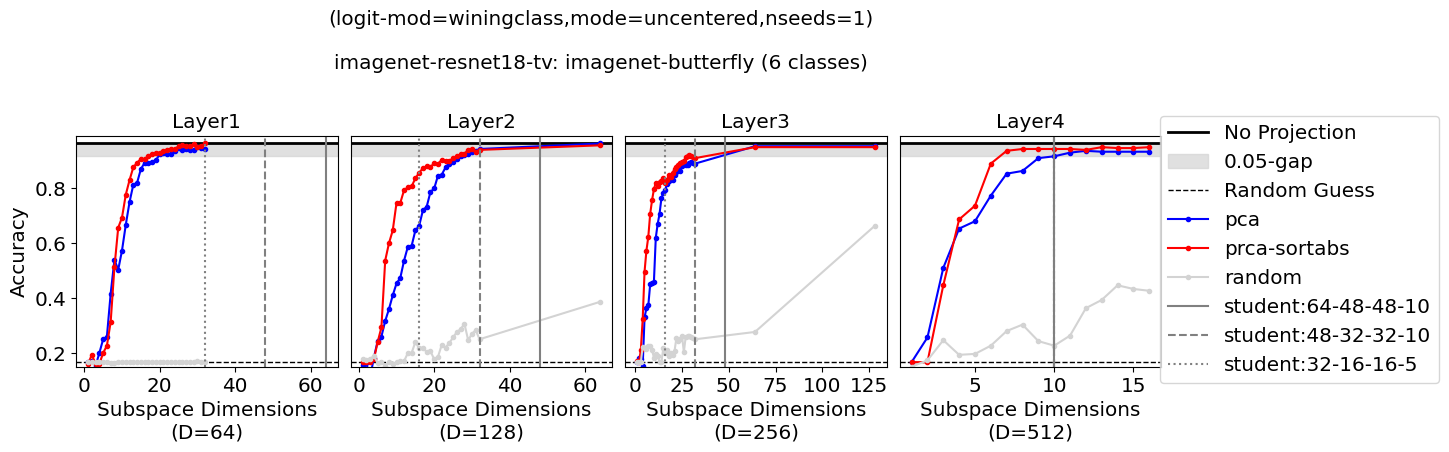

In [30]:
import numpy as np 

def color(name):
    dd = {
        "pca": "blue",
        "prca-sortabs": "red",
        "rel-raw": "red",
        "rel-abs": "red",
        "random": "lightgray",
    }
    
    return dd[name]

    
def alias(name):
    return name

#     dd = {
#         "pca": "PCA",
#         "prca-sortabs": "PRCA-sortabs",
# #         "rel-raw": "Channel Ranking",
# #         "rel-abs": "Channel Ranking(abs)"
#     }
    
#     return dd
    
    
def ls(name):
    dd = {
        "rel-raw": ":",
        "rel-abs": "--"
    }
    
    return dd.get(name, None)

def viz_oneclass(
    arch,
    dataset,
    training_size=1.0, 
    logit_mod="winingclass",
    basis_mode="uncentered", 
    layers=["layer3", "layer4"],
    basis_names=[
        "pca",
        "prca-sortabs",
#         "rel-abs",
#         "rel-raw",    
        "random"
    ],
    seeds=[1],
):
    
    ncols = len(layers)
    gap = 0.05
    fig = plt.figure(figsize=(ncols * 3.5, 3))
    
    arr_ls = ["-", "--", ":"]
    arr_students = [
        "64-48-48-10",
        "48-32-32-10",
        "32-16-16-5",
    ]
    
    for lix, (layer, factor, dims_highlight) in enumerate(layers):
        plt.subplot(1, ncols, lix + 1)
        plt.title(layer.capitalize(), fontsize="x-large")
        plt.ylabel("Accuracy", fontsize="x-large")
        for bix, basis_name in enumerate(basis_names):
            df = load(
                dataset=f"{dataset}--ts{training_size}",
                logit_mod=logit_mod, 
                arch=arch, 
                layer=layer, 
                basis_name=basis_name, basis_mode=basis_mode,
                seeds=seeds,
            )
            d = df["dims"]["first"].values[-1]
            k = df["k"]

            nseeds =df["seed"]["count"].values[-1]
            num_classes = df["num_classes"]["first"].values[0]
            if bix == 0:
                teacher_metric = df["original_acc"]["first"].values[-1]
                plt.axhline(teacher_metric, ls='-', lw=2, color="k", label="No Projection" if lix == 0 else None)
                plt.ylim([1/num_classes - 1/num_classes*0.1 , teacher_metric+0.025])
                  
          
                plt.axhspan(
                    teacher_metric,
                    teacher_metric -gap,
                    alpha=0.7,
                    color="lightgray",
                    label=f"{gap}-gap" if lix == 0 else None
                )

                plt.axhline(1/num_classes, ls="--", lw=1, color="k", label="Random Guess" if lix == 0 else None)


            vcolor = color(basis_name)
            
            if "pcaprca" in basis_name:
                vcolor = plt.gca().lines[-1].get_color()
            
            selected =  k <= factor

            stderr = df["acc"]["std"][selected] / (nseeds ** 0.5)
            mean = df["acc"]["mean"][selected]
            
            
            
            plt.plot(
                k[selected],
                mean,
                label=f"{alias(basis_name)}" if lix == 0 else None,
                color=vcolor,
                ls=ls(basis_name),
                marker="."
            )
            
            plt.fill_between(
                k[selected],
                mean - stderr,
                mean + stderr,
                alpha=0.2,
                color=plt.gca().lines[-1].get_color()
            )
#             if layer == "layer4" and bix == 0:
#                 plt.axvline(
#                     num_classes, ls=":", lw=1, color="gray",
#                     label=f"Number of Classes"
#                 )
                
        for _dix, _dd in enumerate(dims_highlight):
            plt.axvline(
                _dd,
                ls=arr_ls[_dix],
                color="gray",
                label="student:"+arr_students[_dix] if lix == ncols - 1 else None
            )
        
        plt.xlabel(
            f"Subspace Dimensions\n(D={d})",
            fontsize="x-large"
        )
        plt.xticks(fontsize="x-large")
        plt.yticks(fontsize="x-large")
        if lix == 0:
            pass
        else:
            plt.yticks([])
            plt.ylabel("")
    fig.legend(
        fontsize="x-large",
        ncol=1,
        loc="center right",
        borderaxespad=0.1,
        bbox_to_anchor=(1.1, 0.5)
    )
    plt.subplots_adjust(
        wspace=0.05,
    )
    num_classes = df["num_classes"]["first"].values[0]
    plt.suptitle(
        "\n".join(
            [
                f"(logit-mod={logit_mod},mode={basis_mode},nseeds={nseeds})",
                "",
                f"{arch}: {dataset} ({num_classes} classes)",
            ]
        ),
        y=1.3,
        fontsize="x-large"
    )

viz_oneclass(
    arch="imagenet-resnet18-tv",
    dataset="imagenet-butterfly",
    training_size=1.0,
    layers=[
        ("layer1", 32,  [64, 48, 32]),
        ("layer2", 64,  [48, 32, 16]),
        ("layer3", 128, [48, 32, 16]),
        ("layer4", 16,  [10, 10, 10])
    ],
)

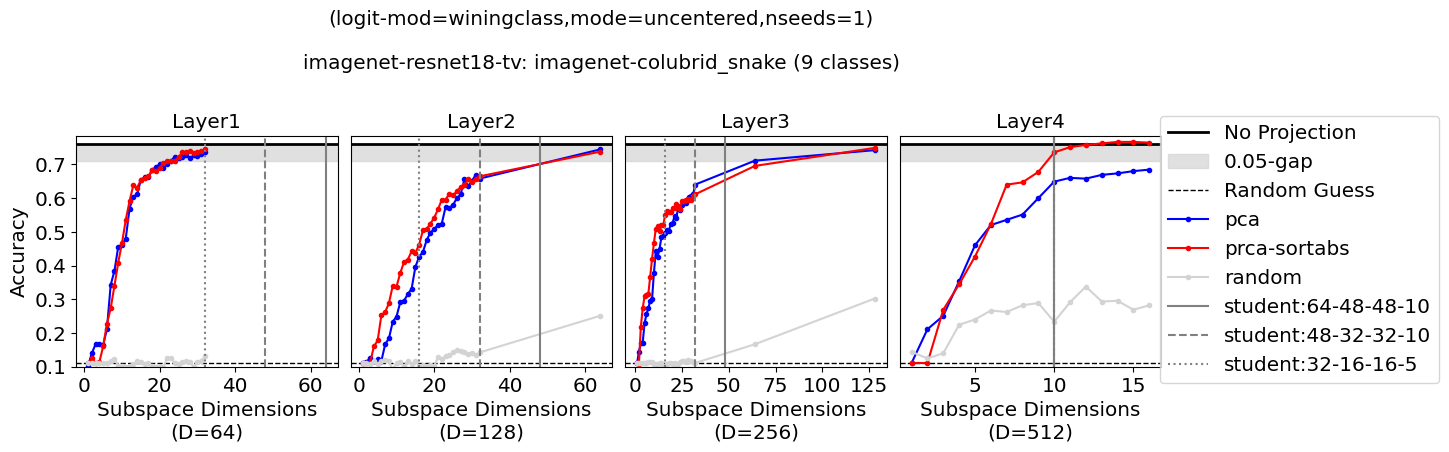

In [32]:
viz_oneclass(
    arch="imagenet-resnet18-tv",
    dataset="imagenet-colubrid_snake",
    training_size=1.0,
    layers=[
        ("layer1", 32,  [64, 48, 32]),
        ("layer2", 64,  [48, 32, 16]),
        ("layer3", 128, [48, 32, 16]),
        ("layer4", 16,  [10, 10, 10])
    ],
)

# Investigate with Multiple Classes

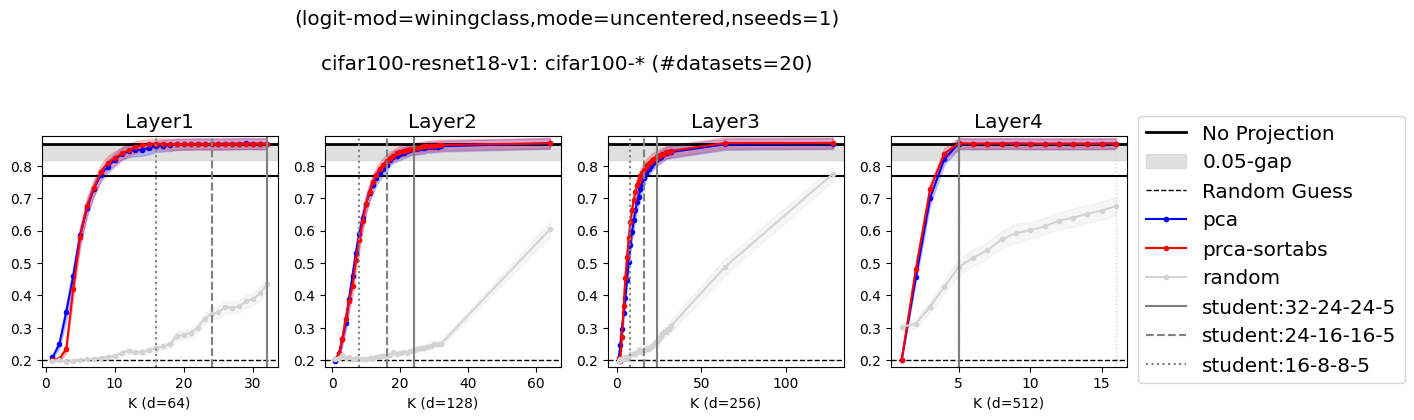

In [33]:

def viz_multiple_datasets(
    arch,
    arr_datasets,
    training_size=1.0, 
    logit_mod="winingclass",
    basis_mode="uncentered", 
    layers=["layer3", "layer4"],
    basis_names=[
        "pca",
        "prca-sortabs",
#         "rel-abs",
#         "rel-raw",    
        "random"
    ],
    seeds=[1],
):
    
    ncols = len(layers)
    gap = 0.05
    fig = plt.figure(figsize=(ncols * 3.5, 3))
    
    arr_ls = ["-", "--", ":"]
    arr_students = [
        "32-24-24-5",
        "24-16-16-5",
        "16-8-8-5",
    ]
    
    for lix, (layer, factor, dims_highlight) in enumerate(layers):
        plt.subplot(1, ncols, lix + 1)
        plt.title(layer.capitalize(), fontsize="x-large")
        plt.ylabel("Accuracy", fontsize="x-large")
        
        for bix, basis_name in enumerate(basis_names):
            
            arr_acc = []
            arr_teacher_acc = []
            for dataset in arr_datasets:
                df = load(
                    dataset=f"{dataset}--ts{training_size}",
                    logit_mod=logit_mod, 
                    arch=arch, 
                    layer=layer, 
                    basis_name=basis_name, basis_mode=basis_mode,
                    seeds=seeds,
                )
                d = df["dims"]["first"].values[-1]
                k = df["k"]
                selected =  k <= factor

                mean = df["acc"]["mean"][selected]
                arr_acc.append(mean)
                arr_teacher_acc.append(df["original_acc"].values[0])
                
            arr_acc = np.array(arr_acc)
#             print("arr_acc.shape", arr_acc.shape)
            _n, _ = arr_acc.shape
            mean = np.mean(arr_acc, axis=0)
            stderr = np.std(arr_acc, axis=0) / (_n ** 0.5)
           
            nseeds =df["seed"]["count"].values[-1]
            num_classes = df["num_classes"]["first"].values[0]
            if bix == 0:
                for __dd in [16, 24]:
                    if __dd <= factor:
                        plt.axvline(__dd, ls=':', lw=1, color="lightgray")

                teacher_metric = np.mean(arr_teacher_acc)
                plt.axhline(teacher_metric, ls='-', lw=2, color="k", label="No Projection" if lix == 0 else None)
                plt.ylim([1/num_classes - 1/num_classes*0.1 , teacher_metric+0.025])
                plt.axhspan(
                    teacher_metric,
                    teacher_metric -gap,
                    alpha=0.7,
                    color="lightgray",
                    label=f"{gap}-gap" if lix == 0 else None
                )
                
                plt.axhline(
                    teacher_metric -gap*2,
#                     alpha=0.7,
                    ls="-",
                    color="black",
#                     label=f"{gap*2}-gap" if lix == 0 else None
                )
                plt.axhline(1/num_classes, ls="--", lw=1, color="k", label="Random Guess" if lix == 0 else None)

            
                plt.ylabel("")
                
            plt.plot(
                k[selected],
                mean,
                label=f"{alias(basis_name)}" if lix == 0 else None,
                color=color(basis_name),
                ls=ls(basis_name),
                marker="."
            )
            
            plt.fill_between(
                k[selected],
                mean - stderr,
                mean + stderr,
                alpha=0.2,
                color=plt.gca().lines[-1].get_color()
            )
            
        for _dix, _dd in enumerate(dims_highlight):
            plt.axvline(
                _dd,
                ls=arr_ls[_dix],
                color="gray",
                label="student:"+arr_students[_dix] if lix == ncols - 1 else None
            )

        plt.xlabel(f"K (d={d})")


    fig.legend(
        fontsize="x-large",
        ncol=1,
        loc="center right",
        borderaxespad=0.1,
        bbox_to_anchor=(1.1, 0.5)
    )
    
    plt.suptitle(
        "\n".join(
            [
                f"(logit-mod={logit_mod},mode={basis_mode},nseeds={nseeds})",
                "",
                f"{arch}: {arr_datasets[0].split('-')[0]}-* (#datasets={len(arr_datasets)})",
            ]
        ),
        y=1.3,
        fontsize="x-large"
    )

viz_multiple_datasets(
    arch="cifar100-resnet18-v1",
    arr_datasets=CIFAR100_SUPECLASSES,
    training_size=1.0,
    layers=[
        ("layer1", 32,  [32, 24, 16]),
        ("layer2", 64,  [24, 16, 8]),
        ("layer3", 128, [24, 16, 8]),
        ("layer4", 16,  [5,   5, 5])
    ],
)